In [1]:
import datasets
from datasets import ResizeAndPad
from torchvision import transforms as T 
import importlib
from matplotlib import pyplot as plt
import numpy as np
from PIL import Image

2024-11-14 11:53:26.924012: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-14 11:53:26.924096: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-14 11:53:26.925452: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-14 11:53:27.758866: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
configs = importlib.import_module(f"configs.ve.fastmri_knee_720_ncsnpp_continuous")
config = configs.get_config()

In [9]:
img_array=np.array(img)

In [10]:
resized_image=image_resize(img_array,0.5)

In [11]:
resized_image.shape

(256, 256, 3)

In [20]:
# Normalize the array to be between 0 and 1
normalized_array = (resized_image - np.min(resized_image)) / (np.max(resized_image) - np.min(resized_image))
display_array = (normalized_array * 255).astype(np.uint8)

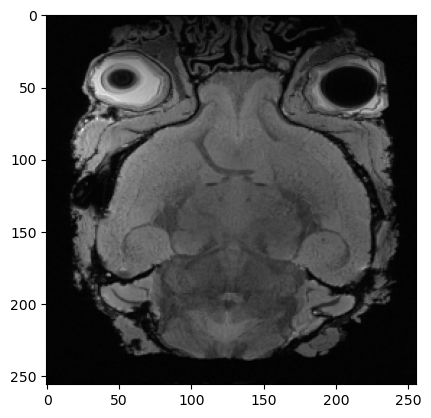

In [21]:
plt.imshow(display_array)

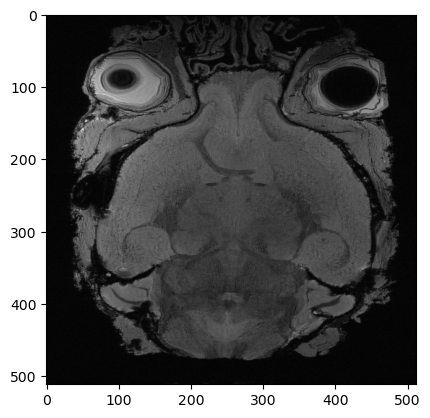

In [22]:
plt.imshow(img)

In [26]:
import numpy as np
from PIL import Image
import os
from matplotlib import pyplot as plt
import torch.nn.functional as F
import torch

def normalize_np(img):
  """ Normalize img in arbitrary range to [0, 1] """
  img -= np.min(img)
  img /= np.max(img)
  return img

def resize_image_torch(image, target_size):
    """Resize the image using PyTorch, expecting a tensor input."""
    # Assuming image is a torch tensor of shape (C, H, W)
    #image = image.unsqueeze(0)  # Add batch dimension
    image=torch.from_numpy(image).unsqueeze(0).unsqueeze(0)
    resized_image = F.interpolate(image, size=(target_size, target_size), mode='bilinear', align_corners=False).squeeze(0).squeeze(0)
    return resized_image.numpy()

def save_images(input_dir, high_res_dir, low_res_dir, scale_factor=2):
    """
    Function to load high-resolution numpy images, save as high-res PNG,
    create low-res versions, and save them as low-res PNG.
    Args:
    input_dir (str): Directory containing high-res numpy images.
    high_res_dir (str): Directory to save high-res PNG images.
    low_res_dir (str): Directory to save low-res PNG images.
    scale_factor (int): Factor by which to downscale the image.
    """
    for file_name in os.listdir(input_dir):
        if file_name.endswith('.npy'):  # Check if the file is a numpy file
            # Construct the full file path
            file_path = os.path.join(input_dir, file_name)
            # Load the numpy image file
            img_array = resize_image_torch(normalize_np(np.load(file_path)),512)
            np.save(f'{high_res_output_dir}/{file_name}', img_array)

            # Ensure the image array is in the correct format (H, W, C)
            if img_array.ndim == 2:
                img_array = np.stack((img_array,) * 3, axis=-1)  # Convert grayscale to RGB if needed

            # Convert numpy array to PIL Image
            img_png=(img_array * 255).astype(np.uint8)
            img = Image.fromarray(img_png, 'RGB')
            # Save the high-resolution image
            high_res_path = os.path.join(high_res_dir, file_name.replace('.npy', '.png'))
            #img.save(high_res_path)
            
            # Resize the image
            img_low_res = image_resize(img_array, 1/scale_factor)
            img_low_array= np.array(img_low_res)
            np.save(f'{low_res_output_dir}/{file_name}', img_low_array[:,:,0])
            # Save the low-resolution image
            img_png=(img_low_res * 255).astype(np.uint8)
            img_low_res = Image.fromarray(img_png, 'RGB')
            low_res_path = os.path.join(low_res_dir, file_name.replace('.npy', '.png'))
            #img_low_res.save(low_res_path)




In [27]:
# Define the directories for input and output
input_dir = '/home/arpanp/MRI_SuperRes/benchmark/data/numpy'
high_res_output_dir = '/home/arpanp/MRI_SuperRes/benchmark/data/test_HR_numpy'
low_res_output_dir = '/home/arpanp/MRI_SuperRes/benchmark/data/test_LR_numpy'

# Create output directories if they don't exist
os.makedirs(high_res_output_dir, exist_ok=True)
os.makedirs(low_res_output_dir, exist_ok=True)
save_images(input_dir, high_res_output_dir, low_res_output_dir)

In [28]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

In [29]:
import torch

In [55]:
torch.load('/home/arpanp/MRI_SuperRes/benchmark/SRGAN-PyTorch/results/SRResNet_x2-SRGAN_ImageNet/g_best.pth.tar')

{'epoch': 128,
 'psnr': 34.53122489929199,
 'ssim': 0.8959805679321289,
 'state_dict': OrderedDict([('_orig_mod.conv1.0.weight',
               tensor([[[[-4.0589e-02, -7.2227e-02, -1.4672e-01,  ...,  6.0261e-02,
                           9.9923e-02,  8.4034e-02],
                         [ 2.4571e-02,  1.5408e-01, -1.7263e-01,  ..., -7.6265e-02,
                          -2.9235e-02,  1.3795e-01],
                         [ 2.0627e-02,  1.3315e-01,  6.0439e-02,  ..., -6.4890e-02,
                           1.1995e-02, -9.1687e-03],
                         ...,
                         [ 8.5022e-02,  1.4005e-01, -8.2553e-02,  ...,  5.8835e-02,
                          -4.3404e-02,  3.1126e-02],
                         [-6.2052e-02, -5.6474e-02, -1.2744e-01,  ..., -9.9884e-02,
                          -5.3188e-02,  3.8435e-02],
                         [-5.1326e-02,  7.4066e-02,  1.0747e-01,  ...,  8.1300e-02,
                           1.0017e-01, -1.4398e-01]],
               
  

In [41]:
from PIL import Image

In [51]:
img=np.load('/home/arpanp/MRI_SuperRes/benchmark/bicubi/numpy/100.npy')

In [54]:
img_array=np.array(img)
img_array.shape

(512, 512)

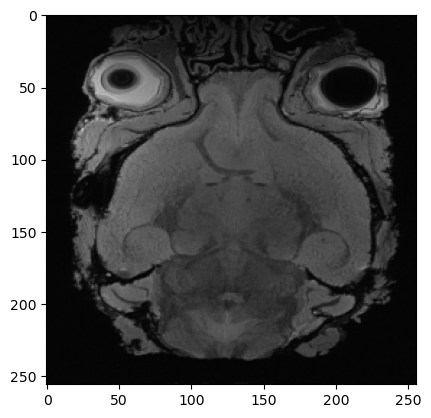

In [36]:
plt.imshow(img)

In [38]:
img=Image.open('/home/arpanp/MRI_SuperRes/benchmark/SRGAN-PyTorch/recon/SRGAN_x2-SRGAN_ImageNet-Set5/100.png')

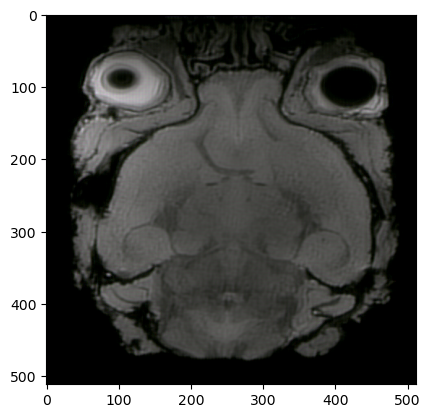

In [39]:
plt.imshow(img)

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [16]:
image = cv2.imread('/home/arpanp/MRI_SuperRes/benchmark/SRCNN-PyTorch/data/mri/SRCNN/train/hr_f1_160_75_0001.png', cv2.IMREAD_GRAYSCALE).astype(np.float32)
image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)/255.0

In [48]:
import cv2
import numpy as np

def unsharp_mask(image, sigma=2, strength=2):
    """Apply unsharp masking to an image using OpenCV.

    Args:
        image (numpy.ndarray): Input image.
        sigma (float): Gaussian kernel standard deviation.
        strength (float): Strength of the sharpening effect.

    Returns:
        numpy.ndarray: Sharpened image.
    """
    # Gaussian blur the image
    blurred = cv2.GaussianBlur(image, (0, 0), sigma)
    
    # Calculate the sharpened image
    sharpened = cv2.addWeighted(image, 1.0 + strength, blurred, -strength, 0)
    
    return sharpened

# Load an image
image = cv2.imread('/home/arpanp/MRI_SuperRes/benchmark/SRCNN-PyTorch/results/test/SRCNN_x2/sr_100.png')
image = image.astype(np.float32) / 255  # Normalize to [0, 1] if needed

# Apply unsharp masking
sharpened_image = unsharp_mask(image)

# Convert back to uint8 and save or display the image
sharpened_image = np.clip(sharpened_image * 255, 0, 255).astype(np.uint8)


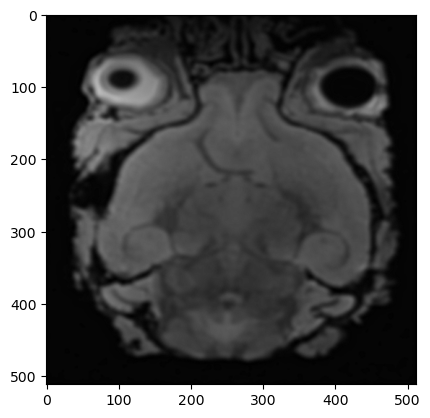

In [49]:
plt.imshow(sharpened_image)

In [68]:
import matplotlib.pyplot as plt
from PIL import Image
import os

def load_images_from_folder(folder):
    """ Load all images in a directory into a list. """
    images = []
    for filename in sorted(os.listdir(folder)):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            img = Image.open(os.path.join(folder, filename))
            if img is not None:
                images.append(img)
    return images

def plot_images(image_folders, titles, cols=3):
    """ Plot a grid of images stored in subdirectories. """
    n = len(image_folders)
    fig, axs = plt.subplots(nrows=n, ncols=cols, figsize=(10, 15))  # Adjusted figure size for better fit

    for row, folder in enumerate(image_folders):
        images = load_images_from_folder(folder)
        for col in range(cols):
            ax = axs[row, col]
            if col < len(images):
                ax.imshow(images[col], cmap='gray')
                ax.axis('off')
            else:
                ax.axis('off')  # Hide unused axes
            if col == 0:
                # Set y-label with more specific alignment and positioning adjustments
                ax.set_ylabel(titles[row], fontsize='large', rotation='horizontal', labelpad=40, verticalalignment='center', horizontalalignment='right')
                
    # Adjust layout for better display of labels and images
    plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.15, right=0.95)
    plt.show()


# Define the path to the main directory and subdirectories
base_path = "/home/arpanp/MRI_SuperRes/benchmark/figures"
methods = ["bicubic","srcnn", "SRGAN", "srresnet",'fmis','HR']
folders = [os.path.join(base_path, method) for method in methods]
titles = ["HR", "Bicubic", "FMIS","as",'asa','ass']

# Plot the images
plot_images(folders, titles)


SyntaxError: invalid syntax (1295879690.py, line 42)

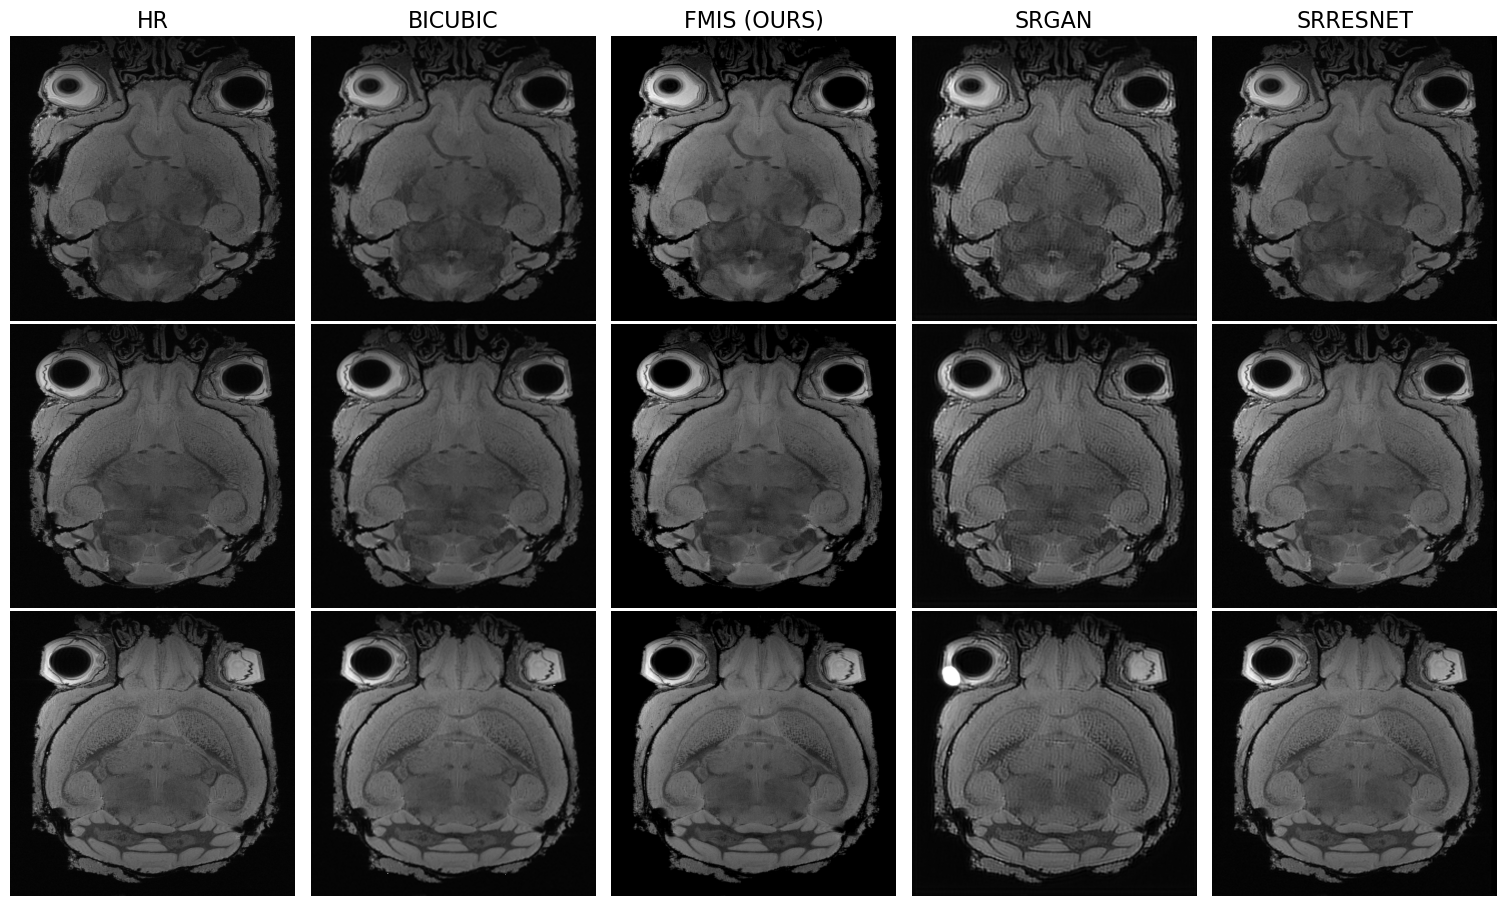

In [27]:
import matplotlib.pyplot as plt
import os
import glob

# Define the folder paths
root_folder = '/home/arpanp/MRI_SuperRes/benchmark/figures'
subfolders = ['HR', 'bicubic', 'fmis', 'SRGAN', 'srresnet']  # Adjusted to reflect actual folder names

# Assuming you know the maximum number of images in any subfolder, set rows appropriately
max_images = 3  # Adjust based on your maximum number of images in any folder
fig, axs = plt.subplots(max_images, len(subfolders), figsize=(20, 10))  # Adjust subplot grid to match the actual layout needed

# Loop through the subfolders and images
for col, subfolder in enumerate(subfolders):
    image_files = sorted(glob.glob(os.path.join(root_folder, subfolder, '*')))  # Ensure only image files are processed
    for row, image_path in enumerate(image_files):
        if row < max_images:  # Prevent indexing beyond the number of available subplots
            img = plt.imread(image_path)
            ax = axs[row, col]
            ax.imshow(img, cmap='gray')  # Assume grayscale, adjust cmap if not appropriate
            ax.axis('off')
        # Set titles with conditional label addition
        title = subfolder.upper() + (" (OURS)" if subfolder == 'fmis' else "")  # Add "Ours" to "fmis"
        if row == 0:
            ax.set_title(title, fontsize=16)

# Adjust the space between subplots to reduce gaps more significantly
plt.subplots_adjust(left=0.1, right=0.85, top=0.93, bottom=0.07, wspace=0.01, hspace=0.01)

# Show the plot
# Save the plot before showing it
save_path = os.path.join(root_folder, 'comparison_of_super_resolution_methods.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

In [1]:
import numpy as np

In [6]:
img=np.load('/home/arpanp/MRI_SuperRes/benchmark/data/test_HR_numpy/100.npy')

In [8]:
img.max()

0.9577468843941402

## Main test

In [6]:
import os
import numpy as np
from skimage import io
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

def calculate_metrics(folder1, folder2):
    """
    Calculates PSNR and SSIM between two sets of images stored in two folders.

    :param folder1: Path to the first folder (reference images).
    :param folder2: Path to the second folder (test images).
    :return: None
    """
    # List files in both directories
    files1 = sorted(os.listdir(folder1))
    files2 = sorted(os.listdir(folder2))
    
    # Initialize lists to store metrics
    psnr_values = []
    ssim_values = []
    
    # Iterate over each file in the first folder
    for file1, file2 in zip(files1, files2):
        # Load the images
        img1 = np.load(os.path.join(folder1, file1))
        img2 = np.load(os.path.join(folder2, file2))
        # Clip the test image values to [0, 1]
        img2 = np.clip(img2, 0, 1)

        # Calculate PSNR and SSIM
        current_psnr = psnr(img1, img2, data_range=img2.max() - img2.min())
        current_ssim = ssim(img1, img2, data_range=img2.max() - img2.min())

        # Store the metrics
        psnr_values.append(current_psnr)
        ssim_values.append(current_ssim)

        # Print results
        print(f"File: {file1} - PSNR: {current_psnr:.2f}, SSIM: {current_ssim:.4f}")

    # Average metrics
    avg_psnr = sum(psnr_values) / len(psnr_values)
    avg_ssim = sum(ssim_values) / len(ssim_values)
    print(f"Average PSNR: {avg_psnr:.2f}, Average SSIM: {avg_ssim:.4f}")




In [7]:
# Example usage
folder1 = '/home/cidar/Desktop/MRI_SuperRes/benchmark/data/test_HR_numpy'  # Update this path
folder2 = '/home/cidar/Desktop/MRI_SuperRes/benchmark/results_wavelet_512_no_xnext_level3_fast_3_comb'        # Update this path
calculate_metrics(folder1, folder2)

File: 100.npy - PSNR: 30.20, SSIM: 0.7612
File: 101.npy - PSNR: 29.68, SSIM: 0.7479
File: 102.npy - PSNR: 28.94, SSIM: 0.7351
File: 103.npy - PSNR: 29.74, SSIM: 0.7430
File: 104.npy - PSNR: 30.16, SSIM: 0.7563
File: 105.npy - PSNR: 29.30, SSIM: 0.7405
File: 106.npy - PSNR: 29.68, SSIM: 0.7524
File: 107.npy - PSNR: 29.54, SSIM: 0.7499
File: 108.npy - PSNR: 29.64, SSIM: 0.7458
File: 109.npy - PSNR: 29.71, SSIM: 0.7562
File: 110.npy - PSNR: 29.82, SSIM: 0.7586
File: 111.npy - PSNR: 29.80, SSIM: 0.7543
File: 112.npy - PSNR: 29.67, SSIM: 0.7498
File: 113.npy - PSNR: 29.57, SSIM: 0.7548
File: 114.npy - PSNR: 29.58, SSIM: 0.7490
File: 115.npy - PSNR: 30.11, SSIM: 0.7616
File: 116.npy - PSNR: 30.37, SSIM: 0.7695
File: 117.npy - PSNR: 30.18, SSIM: 0.7648
File: 118.npy - PSNR: 30.47, SSIM: 0.7691
File: 119.npy - PSNR: 29.92, SSIM: 0.7565
File: 120.npy - PSNR: 30.23, SSIM: 0.7656
File: 121.npy - PSNR: 30.11, SSIM: 0.7677
File: 122.npy - PSNR: 30.07, SSIM: 0.7679
File: 123.npy - PSNR: 29.89, SSIM:

In [8]:
import os
import cv2
import numpy as np
import torch
import lpips
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

def calculate_metrics(sr_image_path, gt_numpy_path, lpips_model, device):
    # Load the super-resolved image as grayscale
    sr_image = np.load(sr_image_path)

    # Load the ground truth image from numpy file
    gt_image = np.load(gt_numpy_path)

    # Convert images to tensors and add a channel dimension
    sr_tensor = torch.from_numpy(sr_image).unsqueeze(0).unsqueeze(0).float().to(device)
    gt_tensor = torch.from_numpy(gt_image).unsqueeze(0).unsqueeze(0).float().to(device)

    # Calculate PSNR and SSIM
    psnr_value = psnr(gt_image, sr_image,data_range=gt_image.max() - gt_image.min())
    ssim_value = ssim(gt_image, sr_image,data_range=gt_image.max() - gt_image.min())

    # Prepare tensors for LPIPS by repeating the channel to make 3-channel images
    sr_tensor_rgb = sr_tensor.repeat(1, 3, 1, 1)
    gt_tensor_rgb = gt_tensor.repeat(1, 3, 1, 1)

    # Calculate LPIPS
    lpips_value = lpips_model(sr_tensor_rgb, gt_tensor_rgb).item()

    return psnr_value, ssim_value, lpips_value

def evaluate_directory(sr_dir, gt_dir, device):
    # Load the LPIPS model
    lpips_model = lpips.LPIPS(net='alex').to(device)  # You can change to 'vgg' if preferred

    psnr_values = []
    ssim_values = []
    lpips_values = []

    sr_files = sorted(os.listdir(sr_dir))
    gt_files = sorted(os.listdir(gt_dir))

    for sr_file, gt_file in zip(sr_files, gt_files):
        sr_path = os.path.join(sr_dir, sr_file)
        gt_path = os.path.join(gt_dir, gt_file)

        psnr_value, ssim_value, lpips_value = calculate_metrics(sr_path, gt_path, lpips_model, device)
        psnr_values.append(psnr_value)
        ssim_values.append(ssim_value)
        lpips_values.append(lpips_value)
        print(f"File: {sr_file} - PSNR: {psnr_value:.2f}, SSIM: {ssim_value:.4f}, LPIPS: {lpips_value:.4f}")

    print(f"Average PSNR: {np.mean(psnr_values):.2f}, Average SSIM: {np.mean(ssim_values):.4f}, Average LPIPS: {np.mean(lpips_values):.4f}")


In [49]:
# Example usage
sr_directory = '/home/cidar/Desktop/MRI_SuperRes/benchmark/bicubi/from_bilinear'
gt_directory = '/home/cidar/Desktop/MRI_SuperRes/benchmark/data/test_HR_numpy'
evaluate_directory(sr_directory, gt_directory,device='cuda')

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/cidar/anaconda3/envs/sup/lib/python3.11/site-packages/lpips/weights/v0.1/alex.pth
File: 100.npy - PSNR: 32.12, SSIM: 0.8615, LPIPS: 0.2150
File: 101.npy - PSNR: 32.43, SSIM: 0.8652, LPIPS: 0.2145
File: 102.npy - PSNR: 31.15, SSIM: 0.8467, LPIPS: 0.2210
File: 103.npy - PSNR: 32.34, SSIM: 0.8636, LPIPS: 0.2124
File: 104.npy - PSNR: 32.11, SSIM: 0.8602, LPIPS: 0.2131
File: 105.npy - PSNR: 31.65, SSIM: 0.8542, LPIPS: 0.2160
File: 106.npy - PSNR: 31.53, SSIM: 0.8524, LPIPS: 0.2214
File: 107.npy - PSNR: 31.51, SSIM: 0.8519, LPIPS: 0.2247
File: 108.npy - PSNR: 31.74, SSIM: 0.8549, LPIPS: 0.2207
File: 109.npy - PSNR: 30.94, SSIM: 0.8446, LPIPS: 0.2252
File: 110.npy - PSNR: 31.22, SSIM: 0.8481, LPIPS: 0.2232
File: 111.npy - PSNR: 31.59, SSIM: 0.8529, LPIPS: 0.2227
File: 112.npy - PSNR: 31.83, SSIM: 0.8564, LPIPS: 0.2197
File: 113.npy - PSNR: 30.91, SSIM: 0.8442, LPIPS: 0.2303
File: 114.npy - PSNR: 

In [18]:
import numpy as np

In [19]:
data=np.load('/home/cidar/Desktop/MRI_SuperRes/benchmark/bicubi/numpy/100.npy')

In [21]:
data.shape

(512, 512)

In [6]:
import torch
import numpy as np
import torch.nn.functional as F
from matplotlib import pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

In [17]:
def normalize_np(img):
  """ Normalize img in arbitrary range to [0, 1] """
  img -= np.min(img)
  img /= np.max(img)
  return img

In [11]:
image=np.load('/home/cidar/Desktop/MRI_SuperRes/studies/study1/LR/59.npy')

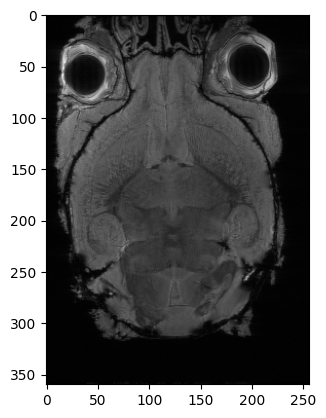

In [7]:
plt.imshow(image,cmap='gray')

In [204]:
image_tensor=torch.from_numpy(image).unsqueeze(0).unsqueeze(0).float()

In [205]:
image_tensor.shape

torch.Size([1, 1, 256, 256])

In [206]:
image_big=F.interpolate(image_tensor, size=(512,512), mode='bicubic', align_corners=False)

In [207]:
image_bicubic=image_big.squeeze(0).squeeze(0).numpy().clip(0,1)

(-0.5, 511.5, 511.5, -0.5)

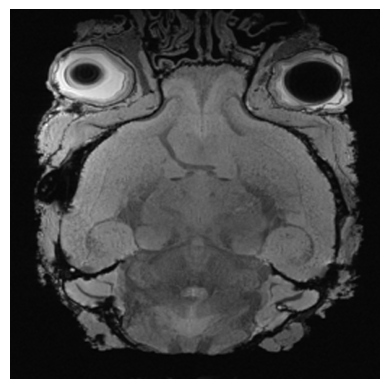

In [208]:
plt.imshow(image_bicubic,cmap='gray')
plt.axis('off')

In [194]:
image_gt=np.load('/home/cidar/Desktop/MRI_SuperRes/benchmark/data/test_HR_numpy/119.npy').clip(0,1)

In [195]:
psnr_value = psnr(image_gt, image_bicubic, data_range=image_gt.max() - image_gt.min())
ssim_value = ssim(image_gt, image_bicubic, data_range=image_gt.max() - image_gt.min())
print(f"PSNR: {psnr_value:.2f}, SSIM: {ssim_value:.4f}")

PSNR: 30.91, SSIM: 0.8001


In [63]:
image_bicubic.min()

0.013435948

In [9]:
#bilinear

In [1]:
import numpy as np
import os
from PIL import Image

# Directory containing .npy files
input_directory = '/home/cidar/Desktop/score-MRI/data_test/AD_F12_91/MRI_25um_normalized'
output_directory = '/home/cidar/Desktop/score-MRI/data_test/AD_F12_91/MRI_25um_png'

# Create the output directory if it does not exist
if not os.path.exists(output_directory):
    os.makedirs(output_directory)

# Function to convert and save .npy file to .png
def convert_np_to_png(np_file, output_path):
    # Load the .npy file
    data = np.load(np_file)
    
    # Normalize the data to the range [0, 255]
    normalized_data = 255 * data
    
    # Convert to uint8 type
    grayscale_image = normalized_data.astype(np.uint8)
    
    # Convert to PIL Image and save as PNG
    image = Image.fromarray(grayscale_image, mode='L')
    image.save(output_path)

# Iterate through all .npy files in the directory
for filename in os.listdir(input_directory):
    if filename.endswith('.npy'):
        np_file_path = os.path.join(input_directory, filename)
        output_file_path = os.path.join(output_directory, filename.replace('.npy', '.png'))
        convert_np_to_png(np_file_path, output_file_path)

print("Conversion completed.")


Conversion completed.


### PCA

In [97]:
import numpy as np
import os
import scipy.ndimage
from sklearn.decomposition import PCA
from sklearn.metrics import euclidean_distances
import heapq
# Paths for input low-res image and high-res image directory
low_res_image_path = '/home/cidar/Desktop/MRI_SuperRes/studies/study1/LR/numpy/86.npy'
high_res_directory = '/home/cidar/Desktop/score-MRI/data_test/AD_F12_91/MRI_25um_normalized'



Top 1 high-res image found: /home/cidar/Desktop/score-MRI/data_test/AD_F12_91/MRI_25um_normalized/170.npy with distance -12.288570419100212


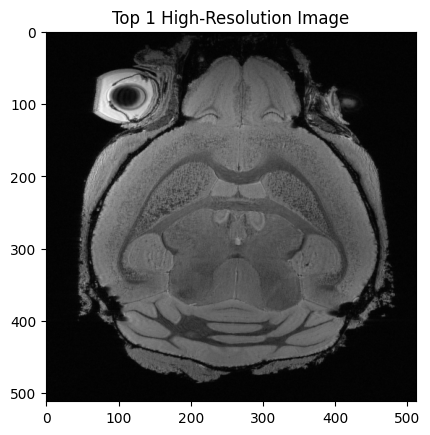

Top 2 high-res image found: /home/cidar/Desktop/score-MRI/data_test/AD_F12_91/MRI_25um_normalized/169.npy with distance -12.531981716256764


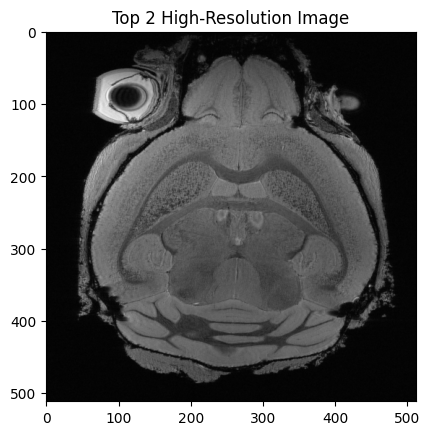

Top 3 high-res image found: /home/cidar/Desktop/score-MRI/data_test/AD_F12_91/MRI_25um_normalized/168.npy with distance -12.537916412444503


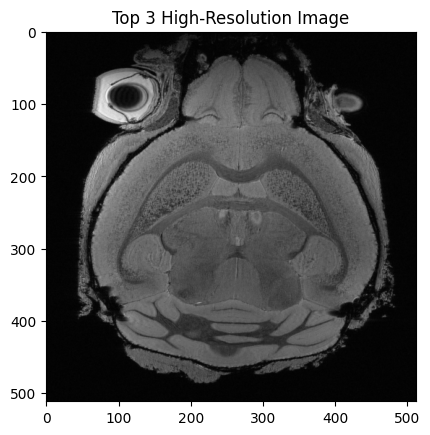

Top 4 high-res image found: /home/cidar/Desktop/score-MRI/data_test/AD_F12_91/MRI_25um_normalized/171.npy with distance -13.676001216381657


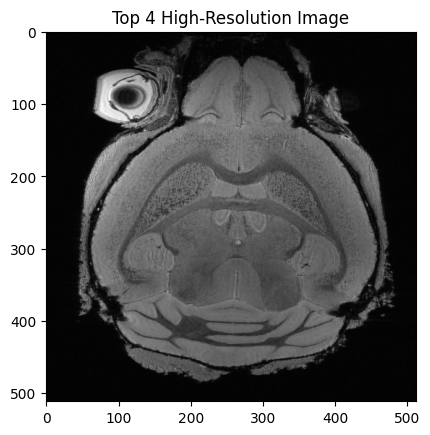

Top 5 high-res image found: /home/cidar/Desktop/score-MRI/data_test/AD_F12_91/MRI_25um_normalized/172.npy with distance -15.814730604387472


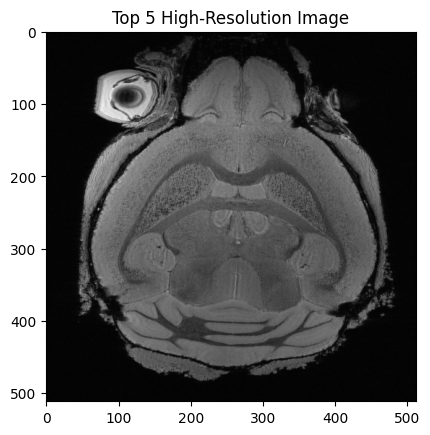

In [98]:
# Load the low-resolution image
low_res_image = np.load(low_res_image_path)

# Ensure the low-res image is 256x256
assert low_res_image.shape == (256, 256), "Low-res image must be 256x256"

# Function to downsample high-res images and apply PCA
def downsample_and_reduce(image, target_size=(256, 256), n_components=50):
    # Downsample the image
    downsampled_image = scipy.ndimage.zoom(image, (target_size[0] / image.shape[0], target_size[1] / image.shape[1]), order=3)
    # Apply PCA
    pca = PCA(n_components=n_components)
    reduced_image = pca.fit_transform(downsampled_image)
    return reduced_image.flatten()

# Reduce the dimensionality of the low-resolution image
low_res_reduced = downsample_and_reduce(low_res_image, n_components=10)

# Initialize variables to find the top 5 closest images
top_5_images = []

# Traverse the high-res image directory
for filename in os.listdir(high_res_directory):
    if filename.endswith('.npy'):
        high_res_image_path = os.path.join(high_res_directory, filename)
        high_res_image = np.load(high_res_image_path)
        
        # Ensure the high-res image is 512x512
        assert high_res_image.shape == (512, 512), f"High-res image {filename} must be 512x512"
        
        # Downsample and reduce the high-res image
        high_res_reduced = downsample_and_reduce(high_res_image, n_components=10)
        
        # Calculate the distance between the low-res and high-res images in the reduced space
        distance = euclidean_distances([low_res_reduced], [high_res_reduced])[0][0]
        
        # Use a heap to keep track of the top 5 closest images
        if len(top_5_images) < 5:
            heapq.heappush(top_5_images, (-distance, high_res_image_path, high_res_image))
        else:
            heapq.heappushpop(top_5_images, (-distance, high_res_image_path, high_res_image))

# Sort the top 5 images by distance
top_5_images = sorted(top_5_images, key=lambda x: -x[0])

# Output the results
import matplotlib.pyplot as plt

for i, (distance, image_path, image) in enumerate(top_5_images):
    print(f"Top {i+1} high-res image found: {image_path} with distance {distance}")
    plt.figure()
    plt.imshow(image, cmap='gray')
    plt.title(f"Top {i+1} High-Resolution Image")
    plt.show()

#### LPIPS

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/cidar/anaconda3/envs/sup/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/cidar/anaconda3/envs/sup/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/cidar/anaconda3/envs/sup/lib/python3.11/site-packages/lpips/weights/v0.1/alex.pth
Top 1 high-res image found: /home/cidar/Desktop/score-MRI/data_test/AD_F12_91/MRI_25um_normalized/169.npy with distance -0.062034569680690765


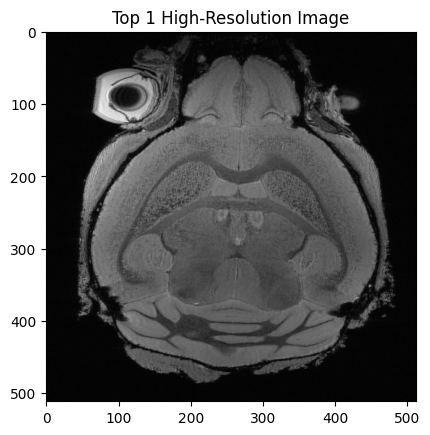

Top 2 high-res image found: /home/cidar/Desktop/score-MRI/data_test/AD_F12_91/MRI_25um_normalized/168.npy with distance -0.06496735662221909


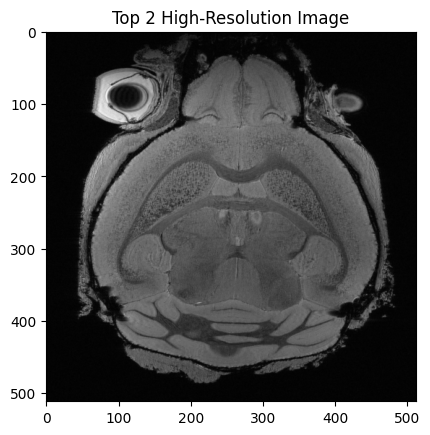

Top 3 high-res image found: /home/cidar/Desktop/score-MRI/data_test/AD_F12_91/MRI_25um_normalized/170.npy with distance -0.06571666896343231


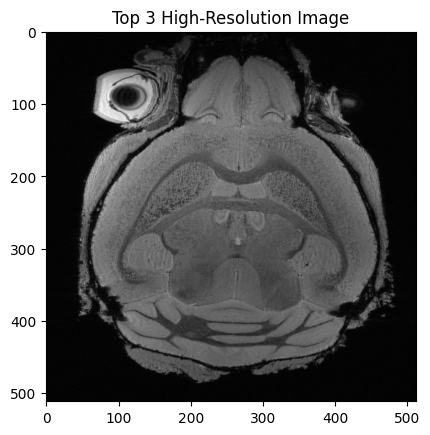

Top 4 high-res image found: /home/cidar/Desktop/score-MRI/data_test/AD_F12_91/MRI_25um_normalized/167.npy with distance -0.07165764272212982


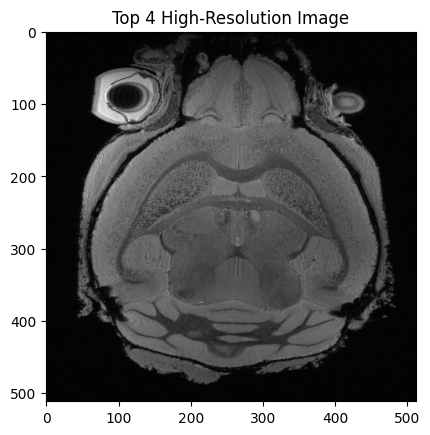

Top 5 high-res image found: /home/cidar/Desktop/score-MRI/data_test/AD_F12_91/MRI_25um_normalized/172.npy with distance -0.07771080732345581


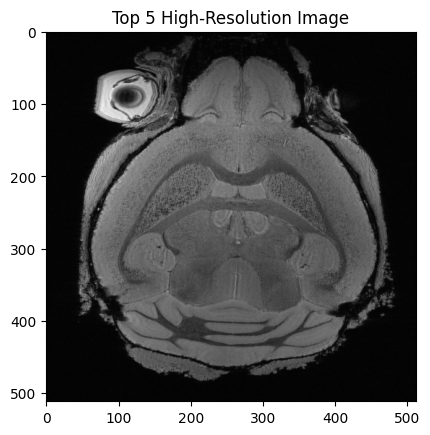

In [99]:
import numpy as np
import os
import torch
import lpips
import scipy.ndimage
import heapq
import matplotlib.pyplot as plt
from PIL import Image

# Initialize LPIPS model
lpips_fn = lpips.LPIPS(net='alex')

# Paths for input low-res image and high-res image directory
# Paths for input low-res image and high-res image directory
low_res_image_path = '/home/cidar/Desktop/MRI_SuperRes/studies/study1/LR/numpy/86.npy'
high_res_directory = '/home/cidar/Desktop/score-MRI/data_test/AD_F12_91/MRI_25um_normalized'
# low_res_image_path = 'path_to_low_res_image.npy'
# high_res_directory = 'path_to_high_res_images'

# Load the low-resolution image
low_res_image = np.load(low_res_image_path)

# Ensure the low-res image is 256x256
assert low_res_image.shape == (256, 256), "Low-res image must be 256x256"

# Function to preprocess the image for LPIPS
def preprocess_image(image, target_size=(256, 256)):
    # Normalize the image to [0, 1]
    normalized_image = (image - np.min(image)) / (np.max(image) - np.min(image))
    # Convert to PIL Image and resize
    pil_image = Image.fromarray((normalized_image * 255).astype(np.uint8)).resize(target_size, Image.BICUBIC)
    # Convert to tensor and unsqueeze to add batch dimension
    tensor_image = torch.tensor(np.array(pil_image)).float() / 255.0
    tensor_image = tensor_image.unsqueeze(0).repeat(3, 1, 1).unsqueeze(0)  # Add batch and channel dimensions
    return tensor_image

# Preprocess the low-resolution image
low_res_tensor = preprocess_image(low_res_image)

# Initialize variables to find the top 5 closest images
top_5_images = []

# Traverse the high-res image directory
for filename in os.listdir(high_res_directory):
    if filename.endswith('.npy'):
        high_res_image_path = os.path.join(high_res_directory, filename)
        high_res_image = np.load(high_res_image_path)
        
        # Ensure the high-res image is 512x512
        assert high_res_image.shape == (512, 512), f"High-res image {filename} must be 512x512"
        
        # Downsample and preprocess the high-res image
        high_res_tensor = preprocess_image(high_res_image)
        
        # Calculate LPIPS distance
        with torch.no_grad():
            distance = lpips_fn(low_res_tensor, high_res_tensor).item()
        
        # Use a heap to keep track of the top 5 closest images
        if len(top_5_images) < 5:
            heapq.heappush(top_5_images, (-distance, high_res_image_path, high_res_image))
        else:
            heapq.heappushpop(top_5_images, (-distance, high_res_image_path, high_res_image))

# Sort the top 5 images by distance
top_5_images = sorted(top_5_images, key=lambda x: -x[0])

# Output the results
for i, (distance, image_path, image) in enumerate(top_5_images):
    print(f"Top {i+1} high-res image found: {image_path} with distance {distance}")
    plt.figure()
    plt.imshow(image, cmap='gray')
    plt.title(f"Top {i+1} High-Resolution Image")
    plt.show()


### SSIM

Top 5 closest images using SSIM:
Top 1 high-res image found: /home/cidar/Desktop/score-MRI/data_test/AD_F12_91/MRI_25um_normalized/170.npy with SSIM 0.6155611241194038


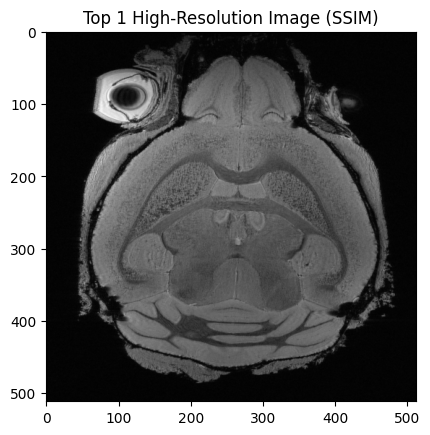

Top 2 high-res image found: /home/cidar/Desktop/score-MRI/data_test/AD_F12_91/MRI_25um_normalized/171.npy with SSIM 0.6144362598479796


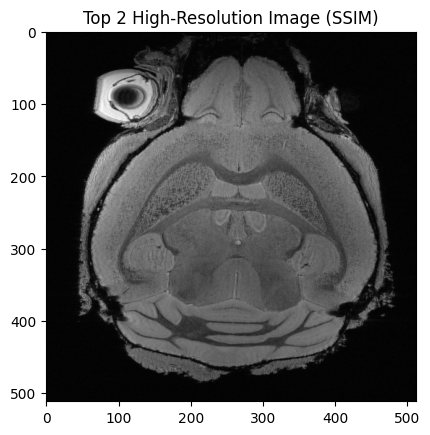

Top 3 high-res image found: /home/cidar/Desktop/score-MRI/data_test/AD_F12_91/MRI_25um_normalized/168.npy with SSIM 0.6071472675772062


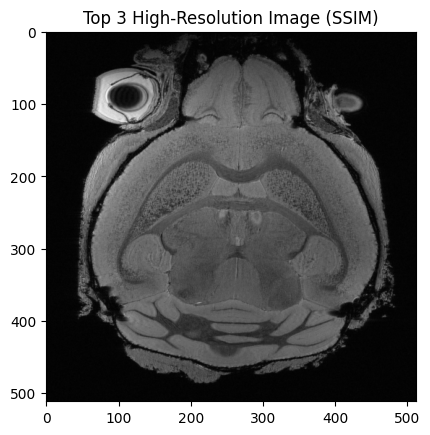

Top 4 high-res image found: /home/cidar/Desktop/score-MRI/data_test/AD_F12_91/MRI_25um_normalized/173.npy with SSIM 0.6055634878025539


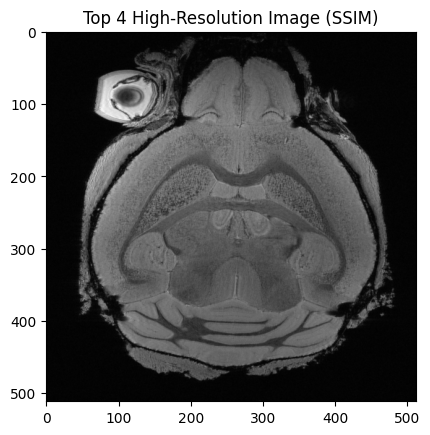

Top 5 high-res image found: /home/cidar/Desktop/score-MRI/data_test/AD_F12_91/MRI_25um_normalized/172.npy with SSIM 0.6031820411325172


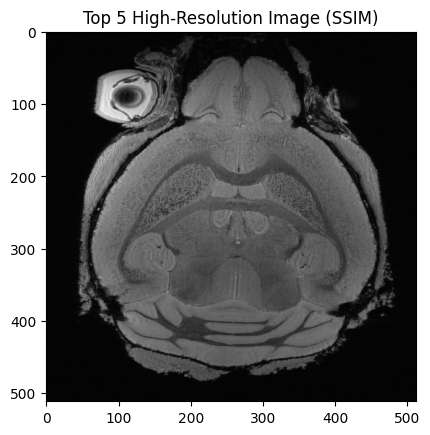

In [100]:
import numpy as np
import os
import scipy.ndimage
import heapq
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import structural_similarity as ssim

# Paths for input low-res image and high-res image directory
low_res_image_path = '/home/cidar/Desktop/MRI_SuperRes/studies/study1/LR/numpy/86.npy'
high_res_directory = '/home/cidar/Desktop/score-MRI/data_test/AD_F12_91/MRI_25um_normalized'

# Load the low-resolution image
low_res_image = np.load(low_res_image_path)

# Ensure the low-res image is 256x256
assert low_res_image.shape == (256, 256), "Low-res image must be 256x256"

# Function to preprocess the image for SSIM
def preprocess_image(image, target_size=(256, 256)):
    # Normalize the image to [0, 1]
    normalized_image = (image - np.min(image)) / (np.max(image) - np.min(image))
    # Convert to PIL Image and resize
    pil_image = Image.fromarray((normalized_image * 255).astype(np.uint8)).resize(target_size, Image.BICUBIC)
    # Convert to numpy array
    array_image = np.array(pil_image).astype(np.float32) / 255.0
    return array_image

# Preprocess the low-resolution image
low_res_image_ssim = preprocess_image(low_res_image)

# Initialize variables to find the top 5 closest images
top_5_images_ssim = []

# Traverse the high-res image directory
for filename in os.listdir(high_res_directory):
    if filename.endswith('.npy'):
        high_res_image_path = os.path.join(high_res_directory, filename)
        high_res_image = np.load(high_res_image_path)
        
        # Ensure the high-res image is 512x512
        assert high_res_image.shape == (512, 512), f"High-res image {filename} must be 512x512"
        
        # Downsample and preprocess the high-res image
        high_res_image_ssim = preprocess_image(high_res_image)
        
        # Calculate SSIM
        distance_ssim = ssim(low_res_image_ssim, high_res_image_ssim, data_range=high_res_image_ssim.max() - high_res_image_ssim.min())
        
        # Use a heap to keep track of the top 5 closest images for SSIM
        if len(top_5_images_ssim) < 5:
            heapq.heappush(top_5_images_ssim, (distance_ssim, high_res_image_path, high_res_image))
        else:
            heapq.heappushpop(top_5_images_ssim, (distance_ssim, high_res_image_path, high_res_image))

# Sort the top 5 images by distance
top_5_images_ssim = sorted(top_5_images_ssim, key=lambda x: -x[0])

# Output the results for SSIM
print("Top 5 closest images using SSIM:")
for i, (distance, image_path, image) in enumerate(top_5_images_ssim):
    print(f"Top {i+1} high-res image found: {image_path} with SSIM {distance}")
    plt.figure()
    plt.imshow(image, cmap='gray')
    plt.title(f"Top {i+1} High-Resolution Image (SSIM)")
    plt.show()


In [5]:
import os
import shutil

# Define the base directory and target directories
base_directory = '/home/cidar/Desktop/score-MRI/results_study1'
numpy_target_directory = '/home/cidar/Desktop/MRI_SuperRes/studies/study1/FMIS/numpy'
png_target_directory = '/home/cidar/Desktop/MRI_SuperRes/studies/study1/FMIS/png'

# Create the target directories if they do not exist
os.makedirs(numpy_target_directory, exist_ok=True)
os.makedirs(png_target_directory, exist_ok=True)

# Traverse the base directory
for root, dirs, files in os.walk(base_directory):
    for file in files:
        # Check if the file is a numpy file
        if file.endswith('.npy'):
            source_file = os.path.join(root, file)
            target_file = os.path.join(numpy_target_directory, file)
            shutil.copy(source_file, target_file)
        
        # Check if the file is a PNG image ending with _clip.png
        elif file.endswith('_clip.png'):
            source_file = os.path.join(root, file)
            target_file = os.path.join(png_target_directory, file.replace('x_clip.png', '.png'))
            shutil.copy(source_file, target_file)

print("Files have been copied successfully.")


Files have been copied successfully.


In [1]:
import cv2
import numpy as np
import torch
from natsort import natsorted
from torch import Tensor
from torch.utils.data import Dataset, DataLoader
from numpy import ndarray
import os
from imgproc import image_resize

In [2]:

def image_to_tensor(image: ndarray, range_norm: bool, half: bool) -> Tensor:
    """Convert the image data type to the Tensor (NCWH) data type supported by PyTorch

    Args:
        image (np.ndarray): The image data read by ``OpenCV.imread``, the data range is [0,255] or [0, 1]
        range_norm (bool): Scale [0, 1] data to between [-1, 1]
        half (bool): Whether to convert torch.float32 similarly to torch.half type

    Returns:
        tensor (Tensor): Data types supported by PyTorch

    Examples:
        >>> example_image = cv2.imread("lr_image.bmp")
        >>> example_tensor = image_to_tensor(example_image, range_norm=True, half=False)

    """
    # Convert image data type to Tensor data type
    tensor = torch.from_numpy(np.ascontiguousarray(image)).unsqueeze(2).permute(2, 0, 1).float()

    # Scale the image data from [0, 1] to [-1, 1]
    if range_norm:
        tensor = tensor.mul(2.0).sub(1.0)

    # Convert torch.float32 image data type to torch.half image data type
    if half:
        tensor = tensor.half()

    return tensor

In [3]:
class BaseImageDataset(Dataset):
    """Define training dataset loading methods."""

    def __init__(
            self,
            gt_images_dir: str,
            lr_images_dir: str = None,
            upscale_factor: int = 4,
    ) -> None:
        """

        Args:
            gt_images_dir (str): Ground-truth image address.
            lr_images_dir (str, optional): Low resolution image address. Default: ``None``
            upscale_factor (int, optional): Image up scale factor. Default: 4
        """

        super(BaseImageDataset, self).__init__()
        # check if the ground truth images folder is empty
        if os.listdir(gt_images_dir) == 0:
            raise RuntimeError("GT image folder is empty.")
        # check if the image magnification meets the model requirements
        if upscale_factor not in [2, 4, 8]:
            raise RuntimeError("Upscale factor must be 2, 4, or 8.")

        # Read a batch of low-resolution images
        if lr_images_dir is None:
            image_file_names = natsorted(os.listdir(gt_images_dir))
            self.lr_image_file_names = None
            self.gt_image_file_names = [os.path.join(gt_images_dir, image_file_name) for image_file_name in image_file_names]
        else:
            if os.listdir(lr_images_dir) == 0:
                raise RuntimeError("LR image folder is empty.")
            image_file_names = natsorted(os.listdir(lr_images_dir))
            self.lr_image_file_names = [os.path.join(lr_images_dir, image_file_name) for image_file_name in image_file_names]
            self.gt_image_file_names = [os.path.join(gt_images_dir, image_file_name) for image_file_name in image_file_names]

        self.upscale_factor = upscale_factor

    def __getitem__(
            self,
            batch_index: int
    ) -> [Tensor, Tensor]:
        # Read a batch of ground truth images
        gt_image = np.load((self.gt_image_file_names[batch_index]))
        #gt_image = cv2.cvtColor(gt_image, cv2.COLOR_BGR2RGB)
        gt_tensor = image_to_tensor(gt_image, False, False)

        # Read a batch of low-resolution images
        if self.lr_image_file_names is not None:
            lr_image = np.load((self.lr_image_file_names[batch_index]))
            #lr_image = cv2.cvtColor(lr_image, cv2.COLOR_BGR2RGB)
            lr_tensor = image_to_tensor(lr_image, False, False)
            print(self.lr_image_file_names[batch_index],self.gt_image_file_names[batch_index])
        else:
            lr_tensor = image_resize(gt_tensor, 1 / self.upscale_factor)

        return {"gt": gt_tensor,
                "lr": lr_tensor}

    def __len__(self) -> int:
        return len(self.gt_image_file_names)

In [4]:
degenerated_train_datasets = BaseImageDataset(
    '/home/cidar/Desktop/MRI_SuperRes/benchmark/data_sensor/supervised/hr',
    '/home/cidar/Desktop/MRI_SuperRes/benchmark/data_sensor/supervised/lr',
        4,
    )

In [5]:
x=next(iter(degenerated_train_datasets))

/home/cidar/Desktop/MRI_SuperRes/benchmark/data_sensor/supervised/lr/0.npy /home/cidar/Desktop/MRI_SuperRes/benchmark/data_sensor/supervised/hr/0.npy


In [29]:
import numpy as np
import matplotlib.pyplot as plt

In [47]:
data=np.load('/home/cidar/Desktop/MRI_SuperRes/benchmark/SRCNN-PyTorch/results/test/SRCNN_x2_sensor/npy/0.npy')

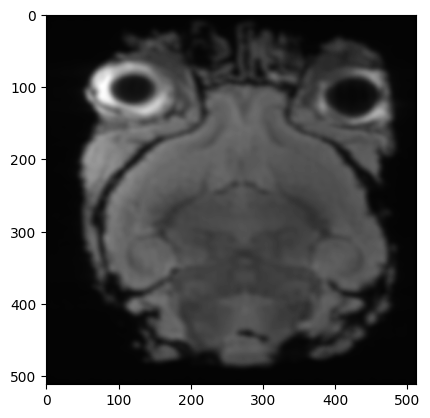

In [48]:
plt.imshow(data,cmap='gray')

In [1]:
import os
import numpy as np
import torch
import lpips
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

def calculate_metrics(ground_truth_folder, superresolved_folder):
    # Initialize LPIPS model
    lpips_fn = lpips.LPIPS(net='alex')

    psnr_values = []
    ssim_values = []
    lpips_values = []

    for filename in os.listdir(ground_truth_folder):
        if filename.endswith('.npy'):
            # Load ground truth and superresolved images
            gt_path = os.path.join(ground_truth_folder, filename)
            sr_path = os.path.join(superresolved_folder, filename)
            
            if not os.path.exists(sr_path):
                print(f"Superresolved image for {filename} not found, skipping...")
                continue
            
            gt_image = np.load(gt_path).astype(np.float32)
            sr_image = np.load(sr_path).astype(np.float32)

            # Calculate PSNR
            psnr_value = psnr(gt_image, sr_image, data_range=1.0)
            psnr_values.append(psnr_value)

            # Calculate SSIM
            ssim_value = ssim(gt_image, sr_image, data_range=1.0)
            ssim_values.append(ssim_value)

            # Calculate LPIPS
            gt_tensor = torch.tensor(gt_image).unsqueeze(0).unsqueeze(0)  # Add batch and channel dimensions
            sr_tensor = torch.tensor(sr_image).unsqueeze(0).unsqueeze(0)  # Add batch and channel dimensions

            lpips_value = lpips_fn(gt_tensor, sr_tensor).item()
            lpips_values.append(lpips_value)

            # Print individual metrics
            print(f"{filename}: PSNR = {psnr_value:.4f}, SSIM = {ssim_value:.4f}, LPIPS = {lpips_value:.4f}")

    # Calculate average metrics
    avg_psnr = np.mean(psnr_values)
    avg_ssim = np.mean(ssim_values)
    avg_lpips = np.mean(lpips_values)

    print(f"Average PSNR: {avg_psnr}")
    print(f"Average SSIM: {avg_ssim}")
    print(f"Average LPIPS: {avg_lpips}")

# Example usage:
ground_truth_folder = '/home/cidar/Desktop/MRI_SuperRes/benchmark/data_sensor/test/hr'
superresolved_folder = '/home/cidar/Desktop/MRI_SuperRes/benchmark/DPS_sensor/numpy'

calculate_metrics(ground_truth_folder, superresolved_folder)


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/cidar/anaconda3/envs/sup/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/cidar/anaconda3/envs/sup/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/cidar/anaconda3/envs/sup/lib/python3.11/site-packages/lpips/weights/v0.1/alex.pth
119.npy: PSNR = 25.9935, SSIM = 0.6348, LPIPS = 0.0987
91.npy: PSNR = 26.5038, SSIM = 0.6986, LPIPS = 0.1037
220.npy: PSNR = 22.5695, SSIM = 0.6446, LPIPS = 0.0976
207.npy: PSNR = 24.4510, SSIM = 0.5867, LPIPS = 0.1492
158.npy: PSNR = 24.1819, SSIM = 0.5628, LPIPS = 0.0930
147.npy: PSNR = 22.7466, SSIM = 0.5875, LPIPS = 0.1072
139.npy: PSNR = 25.7680, SSIM = 0.6412, LPIPS = 0.0911
177.npy: PSNR = 24.5145, SSIM = 0.5515, LPIPS = 0.1077
40.npy: PSNR = 22.8154, SSIM = 0.6296, LPIPS = 0.0947
155.npy: PSNR = 24.7353, SSIM = 0.5740, LPIPS = 0.1089
16.npy: PSNR = 26.2889, SSIM = 0.6214, LPIPS = 0.0980
145.npy: PSNR = 25.6281, SSIM = 0.6259, LPIPS = 0.0909
130.npy: PSNR = 27.3896, SSIM = 0.6707, LPIPS = 0.0862
35.npy: PSNR = 21.3968, SSIM = 0.6053, LPIPS = 0.1114
138.npy: PSNR = 25.9183, SSIM = 0.5734, LPIPS = 0.0893
96.npy: PSNR = 23.7902, SSIM = 0.5392, LPIPS = 0.1068
134.npy: PSNR = 2

In [23]:
import numpy as np

def generate_clipping_ranges(step=0.01):
    ranges = []
    for min_val in np.arange(0, 0.101, step):
        for max_val in np.arange(0.90, 1.01 , step):
            min_val_rounded = round(min_val, 3)
            max_val_rounded = round(max_val, 3)
            ranges.append((min_val_rounded, max_val_rounded))
    return ranges

# Example usage of generate_clipping_ranges
clipping_ranges = generate_clipping_ranges(step=0.01)
print(clipping_ranges)

[(0.0, 0.9), (0.0, 0.91), (0.0, 0.92), (0.0, 0.93), (0.0, 0.94), (0.0, 0.95), (0.0, 0.96), (0.0, 0.97), (0.0, 0.98), (0.0, 0.99), (0.0, 1.0), (0.01, 0.9), (0.01, 0.91), (0.01, 0.92), (0.01, 0.93), (0.01, 0.94), (0.01, 0.95), (0.01, 0.96), (0.01, 0.97), (0.01, 0.98), (0.01, 0.99), (0.01, 1.0), (0.02, 0.9), (0.02, 0.91), (0.02, 0.92), (0.02, 0.93), (0.02, 0.94), (0.02, 0.95), (0.02, 0.96), (0.02, 0.97), (0.02, 0.98), (0.02, 0.99), (0.02, 1.0), (0.03, 0.9), (0.03, 0.91), (0.03, 0.92), (0.03, 0.93), (0.03, 0.94), (0.03, 0.95), (0.03, 0.96), (0.03, 0.97), (0.03, 0.98), (0.03, 0.99), (0.03, 1.0), (0.04, 0.9), (0.04, 0.91), (0.04, 0.92), (0.04, 0.93), (0.04, 0.94), (0.04, 0.95), (0.04, 0.96), (0.04, 0.97), (0.04, 0.98), (0.04, 0.99), (0.04, 1.0), (0.05, 0.9), (0.05, 0.91), (0.05, 0.92), (0.05, 0.93), (0.05, 0.94), (0.05, 0.95), (0.05, 0.96), (0.05, 0.97), (0.05, 0.98), (0.05, 0.99), (0.05, 1.0), (0.06, 0.9), (0.06, 0.91), (0.06, 0.92), (0.06, 0.93), (0.06, 0.94), (0.06, 0.95), (0.06, 0.96), (

In [3]:
import os
import numpy as np
import torch
import lpips
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

def calculate_metrics(ground_truth_folder, superresolved_folder, clipping_range=None):
    # Initialize LPIPS model
    lpips_fn = lpips.LPIPS(net='alex')

    psnr_values = []
    ssim_values = []
    lpips_values = []

    for filename in os.listdir(ground_truth_folder):
        if filename.endswith('.npy'):
            # Load ground truth and superresolved images
            gt_path = os.path.join(ground_truth_folder, filename)
            sr_path = os.path.join(superresolved_folder, filename)
            
            if not os.path.exists(sr_path):
                print(f"Superresolved image for {filename} not found, skipping...")
                continue
            
            gt_image = np.load(gt_path).astype(np.float32)
            sr_image = np.load(sr_path).astype(np.float32)
            
            # Apply clipping if specified
            if clipping_range is not None:
                sr_image = np.clip(sr_image, clipping_range[0], clipping_range[1])
            
            # # Normalize the images to [0, 1] range
            # gt_image /= np.max(gt_image)
            # sr_image /= np.max(sr_image)

            # Calculate PSNR
            psnr_value = psnr(gt_image, sr_image, data_range=1.0)
            psnr_values.append(psnr_value)

            # Calculate SSIM
            ssim_value = ssim(gt_image, sr_image, data_range=1.0)
            ssim_values.append(ssim_value)

            # Calculate LPIPS
            gt_tensor = torch.tensor(gt_image).unsqueeze(0).unsqueeze(0)  # Add batch and channel dimensions
            sr_tensor = torch.tensor(sr_image).unsqueeze(0).unsqueeze(0)  # Add batch and channel dimensions

            lpips_value = lpips_fn(gt_tensor, sr_tensor).item()
            lpips_values.append(lpips_value)

            # Print individual metrics
            print(f"{filename}: PSNR = {psnr_value:.4f}, SSIM = {ssim_value:.4f}, LPIPS = {lpips_value:.4f}")

    # Calculate average metrics
    avg_psnr = np.mean(psnr_values)
    avg_ssim = np.mean(ssim_values)
    avg_lpips = np.mean(lpips_values)

    print(f"Clipping range: {clipping_range}")
    print(f"Average PSNR: {avg_psnr}")
    print(f"Average SSIM: {avg_ssim}")
    print(f"Average LPIPS: {avg_lpips}")
    print("-" * 50)

# Generate clipping ranges with step of 0.05
#clipping_ranges = [0.03, 0.99]

# Example usage:
ground_truth_folder = '/home/arpanp/Downloads/score-MRI/benchmark/test_HR_numpy'
superresolved_folder = '/home/arpanp/Downloads/score-MRI/benchmark/mcg_simu/numpy'
clipping_ranges=None

calculate_metrics(ground_truth_folder, superresolved_folder, clipping_range=clipping_ranges)


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/arpanp/anaconda3/envs/sup/lib/python3.11/site-packages/lpips/weights/v0.1/alex.pth
112.npy: PSNR = 31.3091, SSIM = 0.7912, LPIPS = 0.0747
120.npy: PSNR = 31.2648, SSIM = 0.7905, LPIPS = 0.0768
146.npy: PSNR = 30.9996, SSIM = 0.7925, LPIPS = 0.0725
140.npy: PSNR = 31.0537, SSIM = 0.7909, LPIPS = 0.0749
105.npy: PSNR = 31.3801, SSIM = 0.7923, LPIPS = 0.0753
130.npy: PSNR = 31.0198, SSIM = 0.7897, LPIPS = 0.0747
106.npy: PSNR = 31.2739, SSIM = 0.7915, LPIPS = 0.0713
139.npy: PSNR = 30.9167, SSIM = 0.7903, LPIPS = 0.0713
147.npy: PSNR = 30.9665, SSIM = 0.7910, LPIPS = 0.0742
102.npy: PSNR = 31.2325, SSIM = 0.7911, LPIPS = 0.0727
121.npy: PSNR = 30.7523, SSIM = 0.7865, LPIPS = 0.0699
111.npy: PSNR = 31.1833, SSIM = 0.7886, LPIPS = 0.0736
143.npy: PSNR = 31.1022, SSIM = 0.7909, LPIPS = 0.0714
107.npy: PSNR = 31.0671, SSIM = 0.7895, LPIPS = 0.0724
144.npy: PSNR = 31.1855, SSIM = 0.7916, LPIPS = 0

In [5]:
import numpy as np
import os
from PIL import Image

# Paths for input and output directories
input_directory = '/home/cidar/Desktop/MRI_SuperRes/benchmark/data_sensor/test/lr'  # Directory containing .npy files
output_directory_numpy = '/home/cidar/Desktop/MRI_SuperRes/benchmark/bicubic_sensor/numpy'  # Directory to save superresolved .npy files
output_directory_png = '/home/cidar/Desktop/MRI_SuperRes/benchmark/bicubic_sensor/png'  # Directory to save superresolved .png files

# Create the output directories if they do not exist
os.makedirs(output_directory_numpy, exist_ok=True)
os.makedirs(output_directory_png, exist_ok=True)

# Function to perform 2x superresolution with bicubic interpolation
def superresolve_and_save(np_file, output_dir_numpy, output_dir_png):
    # Load the .npy file
    data = np.load(np_file)
    
    # Normalize the data to the range [0, 255]
    normalized_data = 255 * data
    
    # Convert to uint8 type
    grayscale_image = normalized_data.astype(np.uint8)
    
    # Convert to PIL Image
    image = Image.fromarray(grayscale_image, mode='L')
    
    # Perform bicubic interpolation for 2x superresolution
    new_size = (image.width * 2, image.height * 2)
    superresolved_image = image.resize(new_size, Image.BICUBIC)
    
    # Convert back to numpy array
    superresolved_data = np.array(superresolved_image)/255
    
    # Create output file names
    base_filename = os.path.basename(np_file).replace('.npy', '')
    png_output_path = os.path.join(output_dir_png, f"{base_filename}.png")
    npy_output_path = os.path.join(output_dir_numpy, f"{base_filename}.npy")
    
    # Save the image as PNG
    superresolved_image.save(png_output_path)
    
    # Save the superresolved data as a .npy file
    np.save(npy_output_path, superresolved_data)

# Iterate through all .npy files in the input directory
for filename in os.listdir(input_directory):
    if filename.endswith('.npy'):
        np_file_path = os.path.join(input_directory, filename)
        superresolve_and_save(np_file_path, output_directory_numpy, output_directory_png)

print("Superresolution and saving completed.")


Superresolution and saving completed.


In [14]:
import numpy as np
import os
from PIL import Image

# Directory containing .np files
input_directory = '/home/cidar/Desktop/MRI_SuperRes/benchmark/FMIS_SENSOR/npy'
output_directory = '/home/cidar/Desktop/MRI_SuperRes/benchmark/FMIS_SENSOR/png'

# Create the output directory if it does not exist
if not os.path.exists(output_directory):
    os.makedirs(output_directory)

# Function to convert and save .np file to .png
def convert_np_to_png(np_file, output_path):
    # Load the .np file
    data = np.load(np_file).clip(0.03, 0.95)
    
    # Normalize the data to the range [0, 255]
    normalized_data = 255 * data
    
    # Convert to uint8 type
    grayscale_image = normalized_data.astype(np.uint8)
    
    # Convert to PIL Image and save as PNG
    image = Image.fromarray(grayscale_image, mode='L')
    image.save(output_path)

# Iterate through all .np files in the directory
for filename in os.listdir(input_directory):
    if filename.endswith('.npy'):
        np_file_path = os.path.join(input_directory, filename)
        output_file_path = os.path.join(output_directory, filename.replace('.npy', '.png'))
        convert_np_to_png(np_file_path, output_file_path)

print("Conversion completed.")


Conversion completed.


In [29]:
import os
import shutil

def copy_and_rename_images(src_folder, dest_folder, prefix, num_images):
    # Ensure the destination folder exists
    os.makedirs(dest_folder, exist_ok=True)
    
    for i in range(num_images):
        # Construct the source and destination file paths
        src_file = os.path.join(src_folder, f"{i}.png")
        dest_file = os.path.join(dest_folder, f"{i}_{prefix}.png")
        
        # Check if the source file exists before copying
        if os.path.exists(src_file):
            shutil.copy(src_file, dest_file)
            print(f"Copied {src_file} to {dest_file}")
        else:
            print(f"Source file {src_file} does not exist, skipping...")

# Example usage:
src_folder = '/home/cidar/Desktop/MRI_SuperRes/benchmark/bicubic_sensor/png'
dest_folder = '/home/cidar/Desktop/MRI_SuperRes/studies/study1/BICUBIC'
prefix = 'bicubic'
num_images = 50

copy_and_rename_images(src_folder, dest_folder, prefix, num_images)


Copied /home/cidar/Desktop/MRI_SuperRes/benchmark/bicubic_sensor/png/0.png to /home/cidar/Desktop/MRI_SuperRes/studies/study1/BICUBIC/0_bicubic.png
Copied /home/cidar/Desktop/MRI_SuperRes/benchmark/bicubic_sensor/png/1.png to /home/cidar/Desktop/MRI_SuperRes/studies/study1/BICUBIC/1_bicubic.png
Copied /home/cidar/Desktop/MRI_SuperRes/benchmark/bicubic_sensor/png/2.png to /home/cidar/Desktop/MRI_SuperRes/studies/study1/BICUBIC/2_bicubic.png
Copied /home/cidar/Desktop/MRI_SuperRes/benchmark/bicubic_sensor/png/3.png to /home/cidar/Desktop/MRI_SuperRes/studies/study1/BICUBIC/3_bicubic.png
Copied /home/cidar/Desktop/MRI_SuperRes/benchmark/bicubic_sensor/png/4.png to /home/cidar/Desktop/MRI_SuperRes/studies/study1/BICUBIC/4_bicubic.png
Copied /home/cidar/Desktop/MRI_SuperRes/benchmark/bicubic_sensor/png/5.png to /home/cidar/Desktop/MRI_SuperRes/studies/study1/BICUBIC/5_bicubic.png
Copied /home/cidar/Desktop/MRI_SuperRes/benchmark/bicubic_sensor/png/6.png to /home/cidar/Desktop/MRI_SuperRes/s

In [30]:
import os
import shutil

# Define paths
methods_path = '/home/cidar/Desktop/MRI_SuperRes/studies/study1'
images_path = '/home/cidar/Desktop/MRI_SuperRes/studies/study1_website'

# Ensure the output directory exists
os.makedirs(images_path, exist_ok=True)

# Gather all method folders
methods = [name for name in os.listdir(methods_path) if os.path.isdir(os.path.join(methods_path, name))]

# Process each method folder
for method in methods:
    method_folder = os.path.join(methods_path, method)
    
    # List all files in the method folder
    for filename in os.listdir(method_folder):
        if filename.endswith('.png'):
            # Extract the image index from the filename
            index = filename.split('_')[0]
            
            # Define the target folder based on the index
            target_folder = os.path.join(images_path, f'images{index.zfill(3)}')
            os.makedirs(target_folder, exist_ok=True)
            
            # Define the source and target file paths
            source_file = os.path.join(method_folder, filename)
            target_file = os.path.join(target_folder, filename)
            
            # Move the file
            shutil.move(source_file, target_file)

print("Images have been organized successfully.")


Images have been organized successfully.


In [1]:
import os
import shutil

# Define the base directory and target directories
base_directory = '/home/arpanp/Downloads/score-MRI/results_mcg_simu'
numpy_target_directory = '/home/arpanp/Downloads/score-MRI/benchmark/mcg_simu/numpy'
png_target_directory = '/home/arpanp/Downloads/score-MRI/benchmark/mcg_simu/png'

# Create the target directories if they do not exist
os.makedirs(numpy_target_directory, exist_ok=True)
os.makedirs(png_target_directory, exist_ok=True)

# Traverse the base directory
for root, dirs, files in os.walk(base_directory):
    for file in files:
        # Check if the file is a numpy file
        if file.endswith('.npy'):
            source_file = os.path.join(root, file)
            target_file = os.path.join(numpy_target_directory, file)
            shutil.copy(source_file, target_file)
        
        # Check if the file is a PNG image ending with _clip.png
        elif file.endswith('_clip.png'):
            source_file = os.path.join(root, file)
            target_file = os.path.join(png_target_directory, file.split('x_clip')[0] + '.png')
            shutil.copy(source_file, target_file)

print("Files have been copied successfully.")


Files have been copied successfully.
